# This contains some code that would be relevant to fine hand masking of the dataset only, for coarse masking by ref spectra, these are not really appliccable

In [2]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
parent_dir = Path().resolve().parent
sys.path.insert(0, str(parent_dir))
#print(parent_dir)
from utils.dataset import UniversalDataset

In [3]:
file = pd.ExcelFile(parent_dir / 'pivot_table.xlsx')
file.sheet_names


['Oil_dataset',
 '4_feb_spectrophotometer',
 'oil_grams',
 'oil_dataset_final',
 'Sheet5',
 'rgb_hsi_converter',
 'reconstruction methods',
 'hyperspectral datasets',
 'oils']

In [159]:
import pandas as pd
df = pd.read_excel(parent_dir / 'pivot_table.xlsx', sheet_name = 'oil_dataset_final')
ref_spec = pd.read_csv('C:/Users/4spam/evoo/masking_business/ref_spectra.csv')

In [160]:
df['oil'].unique()

array(['sunflower', nan, 'GAEA_100_0', 'GAEA_99_1', 'GAEA_98_2',
       'GAEA_97_3', 'GAEA_96_4', 'GAEA_95_5', 'GAEA_94_6', 'GAEA_92_8',
       'GAEA_90_10', 'GAEA_85_15', 'GAEA_80_20', 'GAEA_75_25',
       'GAEA_70_30', 'GAEA_65_35', 'GAEA_60_40', 'GAEA_55_45',
       'GAEA_50_50', 'GAEA_40_60', 'GAEA_30_70', 'GAEA_15_85'],
      dtype=object)

In [161]:
df = df.dropna(subset = ['id'])

In [162]:
df = df[np.array([int(i) > 1000 for i in df['id'].values])]

In [163]:
df['id'] = df['id'].astype(int)
df.reset_index(drop = True, inplace = True)
df['id']

0      2599
1      2600
2      2601
3      2602
4      2603
       ... 
627    3252
628    3253
629    3254
630    3255
631    3256
Name: id, Length: 632, dtype: int32

In [9]:
ref_spec.columns

Index(['id', 'wave_0', 'wave_1', 'wave_2', 'wave_3', 'wave_4', 'wave_5',
       'wave_6', 'wave_7', 'wave_8',
       ...
       'wave_194', 'wave_195', 'wave_196', 'wave_197', 'wave_198', 'wave_199',
       'wave_200', 'wave_201', 'wave_202', 'wave_203'],
      dtype='object', length=205)

In [164]:
spec_ids = df['id']
for i in spec_ids:
    ref_spec.loc[ref_spec['id'] == i, 'oil'] = df.loc[df['id'] == i, 'oil'].values[0]

In [165]:
ref_spec = ref_spec.dropna(subset = ['oil'])

In [12]:
ds = UniversalDataset(root_dir = 'D:\\oil\\', meta = df, load_hsi = True, load_mask = True, crop_size = 512, mask_dir = 'C:\\Users\\4spam\\evoo\\masking_business\\hand_masks\\')

In [13]:
df['oil'].unique()

array(['sunflower', 'GAEA_100_0', 'GAEA_99_1', 'GAEA_98_2', 'GAEA_97_3',
       'GAEA_96_4', 'GAEA_95_5', 'GAEA_94_6', 'GAEA_92_8', 'GAEA_90_10',
       'GAEA_85_15', 'GAEA_80_20', 'GAEA_75_25', 'GAEA_70_30',
       'GAEA_65_35', 'GAEA_60_40', 'GAEA_55_45', 'GAEA_50_50',
       'GAEA_40_60', 'GAEA_30_70', 'GAEA_15_85'], dtype=object)

In [14]:
import numpy as np
waves = np.load('C:/Users/4spam/evoo/binning/waves_specim_iq.npy')

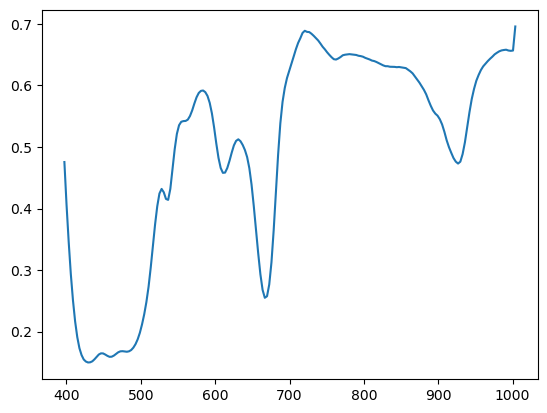

In [14]:
import matplotlib.pyplot as plt
mu = ref_spec.drop(columns = ['id', 'oil']).mean(axis = 0)
std = ref_spec.drop(columns = ['id', 'oil']).std(axis = 0)
plt.plot(waves, mu)
plt.show()



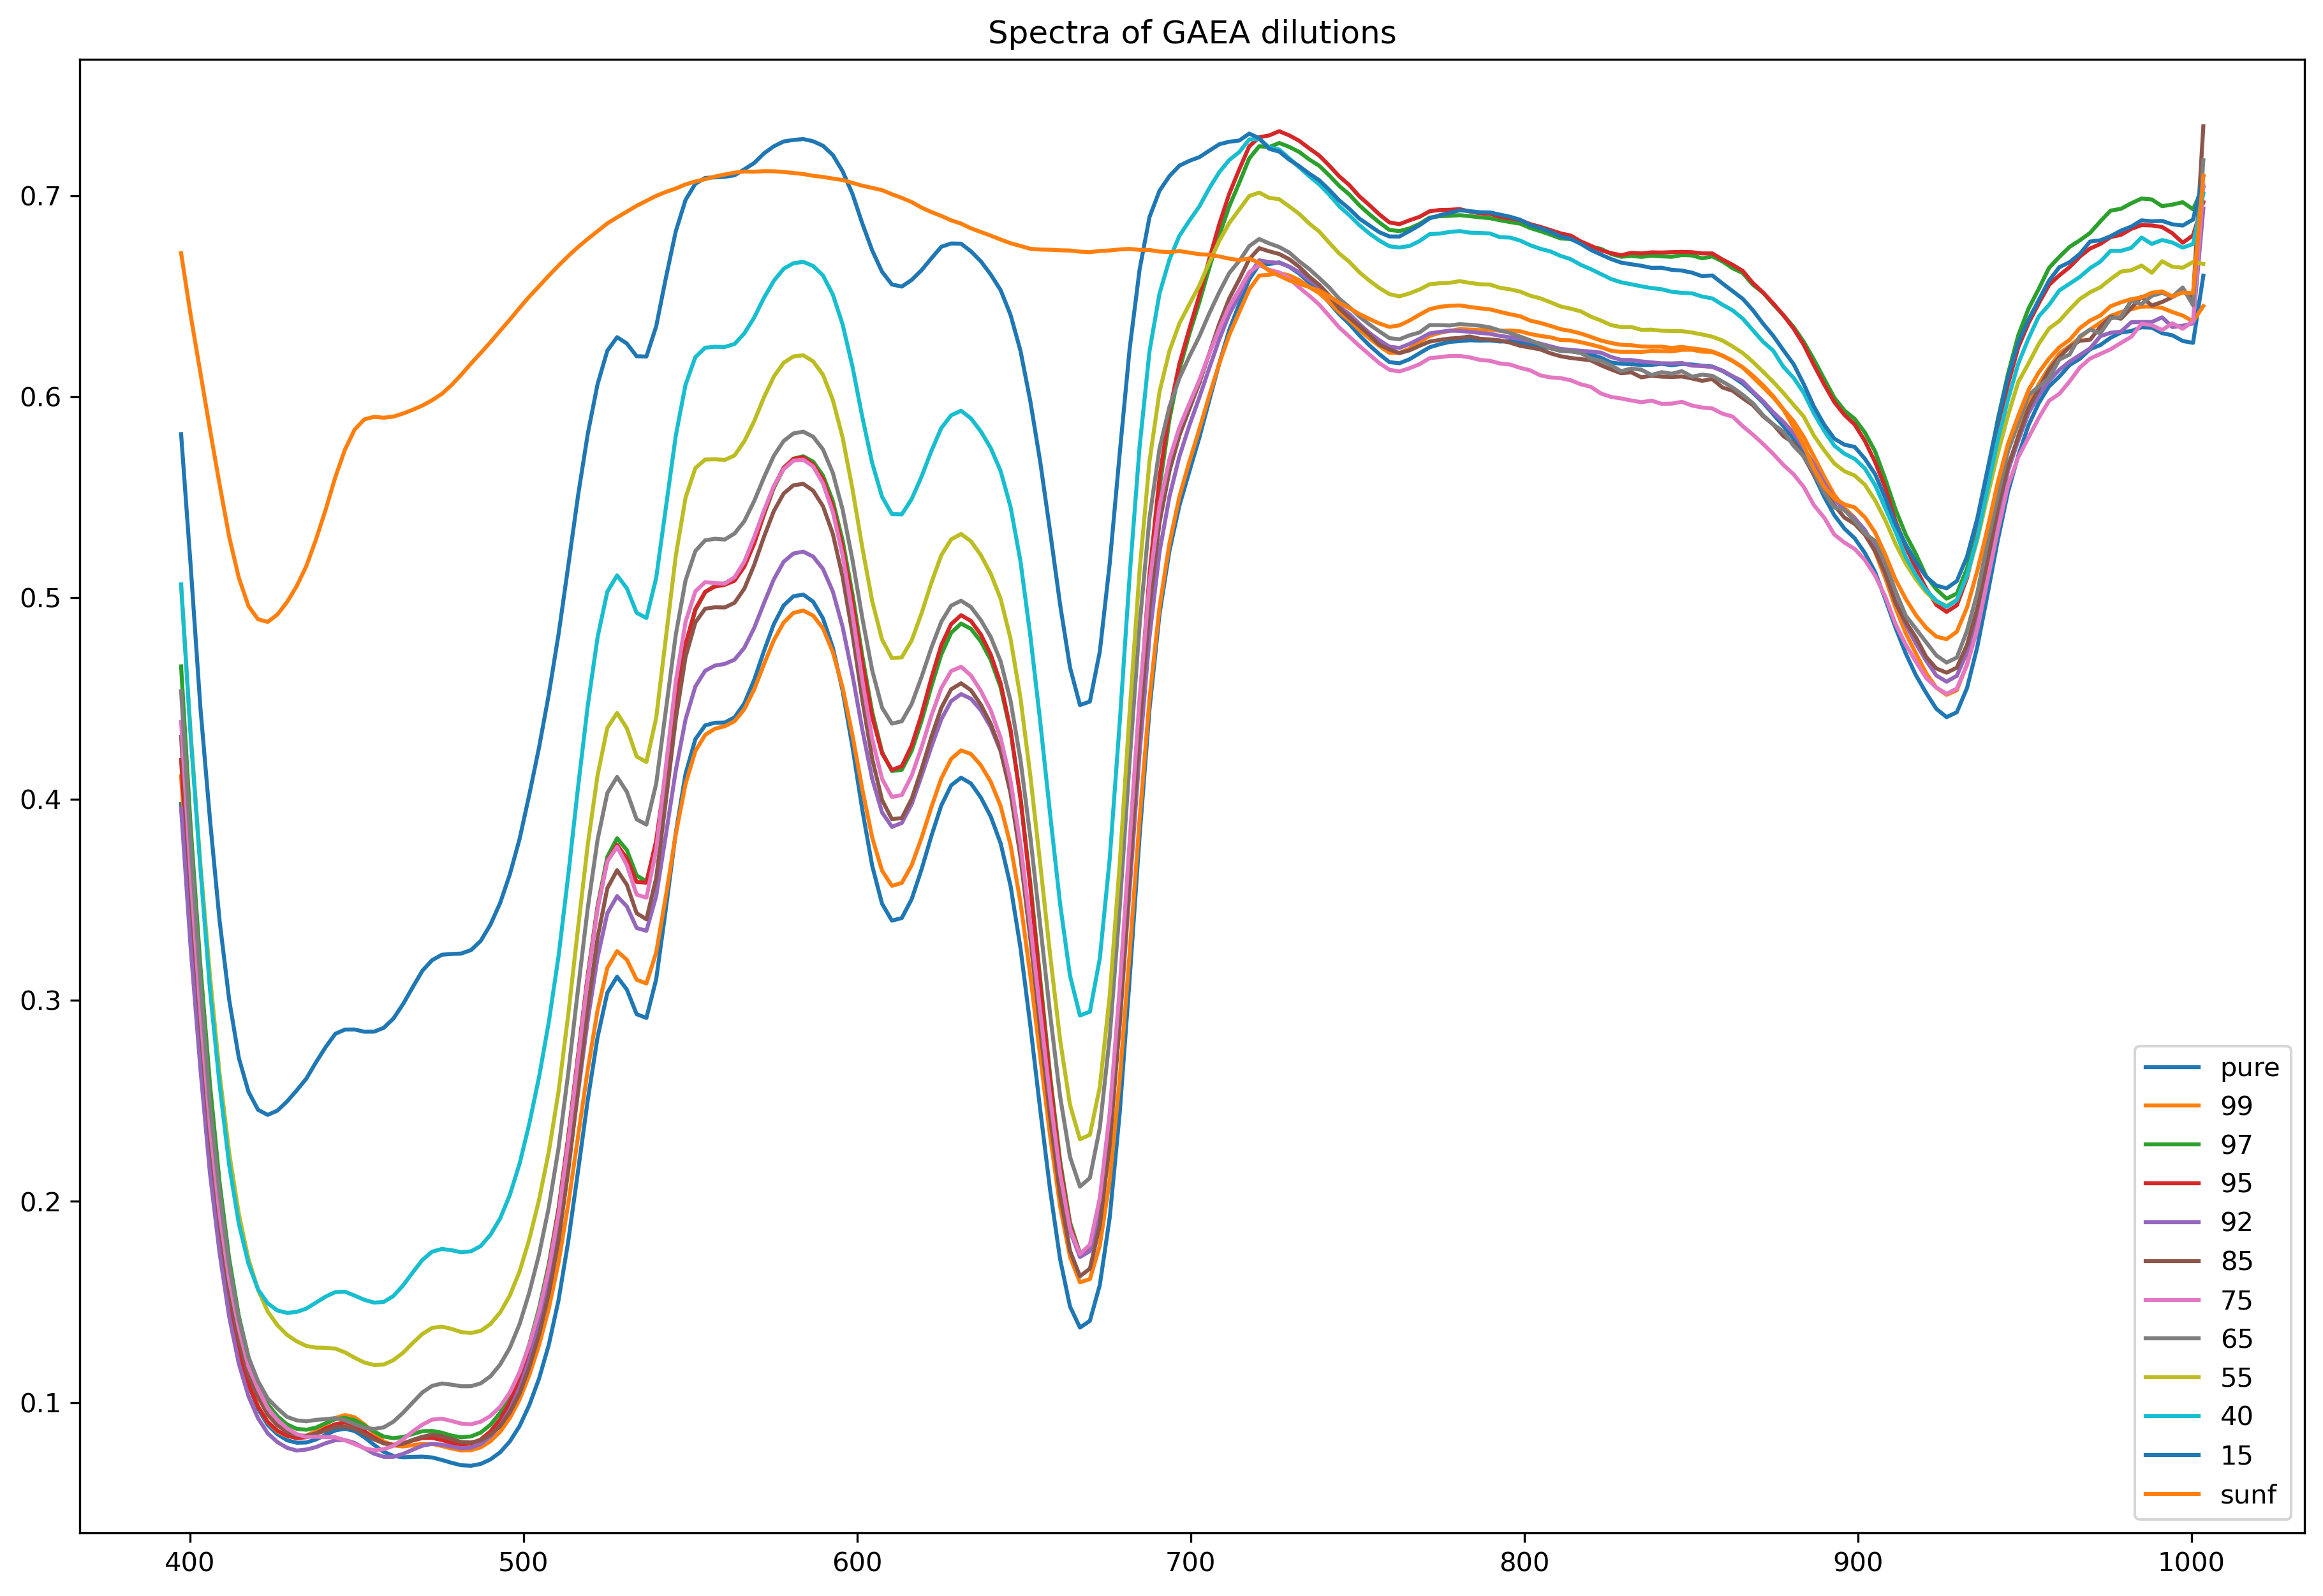

In [16]:

plt.figure(figsize = (15, 10), dpi = 300)
plt.plot(waves, (ref_spec[ref_spec['oil'] == 'GAEA_100_0'].drop(columns = ['id', 'oil']).mean(axis = 0)), label = 'pure')
plt.plot(waves, (ref_spec[ref_spec['oil'] == 'GAEA_99_1'].drop(columns = ['id', 'oil']).mean(axis = 0)), label = '99')
#plt.plot(waves, (ref_spec[ref_spec['oil'] == 'GAEA_98_2'].drop(columns = ['id', 'oil']).mean(axis = 0)), label = '98')
plt.plot(waves, (ref_spec[ref_spec['oil'] == 'GAEA_97_3'].drop(columns = ['id', 'oil']).mean(axis = 0)), label = '97')
#plt.plot(waves, (ref_spec[ref_spec['oil'] == 'GAEA_96_4'].drop(columns = ['id', 'oil']).mean(axis = 0)), label = '96')
plt.plot(waves, (ref_spec[ref_spec['oil'] == 'GAEA_95_5'].drop(columns = ['id', 'oil']).mean(axis = 0)), label = '95')
#plt.plot(waves, (ref_spec[ref_spec['oil'] == 'GAEA_94_6'].drop(columns = ['id', 'oil']).mean(axis = 0)), label = '94')
plt.plot(waves, (ref_spec[ref_spec['oil'] == 'GAEA_92_8'].drop(columns = ['id', 'oil']).mean(axis = 0)), label = '92')
#plt.plot(waves, (ref_spec[ref_spec['oil'] == 'GAEA_90_10'].drop(columns = ['id', 'oil']).mean(axis = 0)), label = '90')
plt.plot(waves, (ref_spec[ref_spec['oil'] == 'GAEA_85_15'].drop(columns = ['id', 'oil']).mean(axis = 0)), label = '85')
#plt.plot(waves, (ref_spec[ref_spec['oil'] == 'GAEA_80_20'].drop(columns = ['id', 'oil']).mean(axis = 0)), label = '80')
plt.plot(waves, (ref_spec[ref_spec['oil'] == 'GAEA_75_25'].drop(columns = ['id', 'oil']).mean(axis = 0)), label = '75')
#plt.plot(waves, (ref_spec[ref_spec['oil'] == 'GAEA_70_30'].drop(columns = ['id', 'oil']).mean(axis = 0)), label = '70')
plt.plot(waves, (ref_spec[ref_spec['oil'] == 'GAEA_65_35'].drop(columns = ['id', 'oil']).mean(axis = 0)), label = '65')
#plt.plot(waves, (ref_spec[ref_spec['oil'] == 'GAEA_60_40'].drop(columns = ['id', 'oil']).mean(axis = 0)), label = '60')
plt.plot(waves, (ref_spec[ref_spec['oil'] == 'GAEA_55_45'].drop(columns = ['id', 'oil']).mean(axis = 0)), label = '55')
#plt.plot(waves, (ref_spec[ref_spec['oil'] == 'GAEA_50_50'].drop(columns = ['id', 'oil']).mean(axis = 0)), label = '50')
plt.plot(waves, (ref_spec[ref_spec['oil'] == 'GAEA_40_60'].drop(columns = ['id', 'oil']).mean(axis = 0)), label = '40')
#plt.plot(waves, (ref_spec[ref_spec['oil'] == 'GAEA_30_70'].drop(columns = ['id', 'oil']).mean(axis = 0)), label = '30')
plt.plot(waves, (ref_spec[ref_spec['oil'] == 'GAEA_15_85'].drop(columns = ['id', 'oil']).mean(axis = 0)), label = '15')
plt.plot(waves, (ref_spec[ref_spec['oil'] == 'sunflower'].drop(columns = ['id', 'oil']).mean(axis = 0)), label = 'sunf')
plt.title('Spectra of GAEA dilutions')
plt.legend()
plt.show()


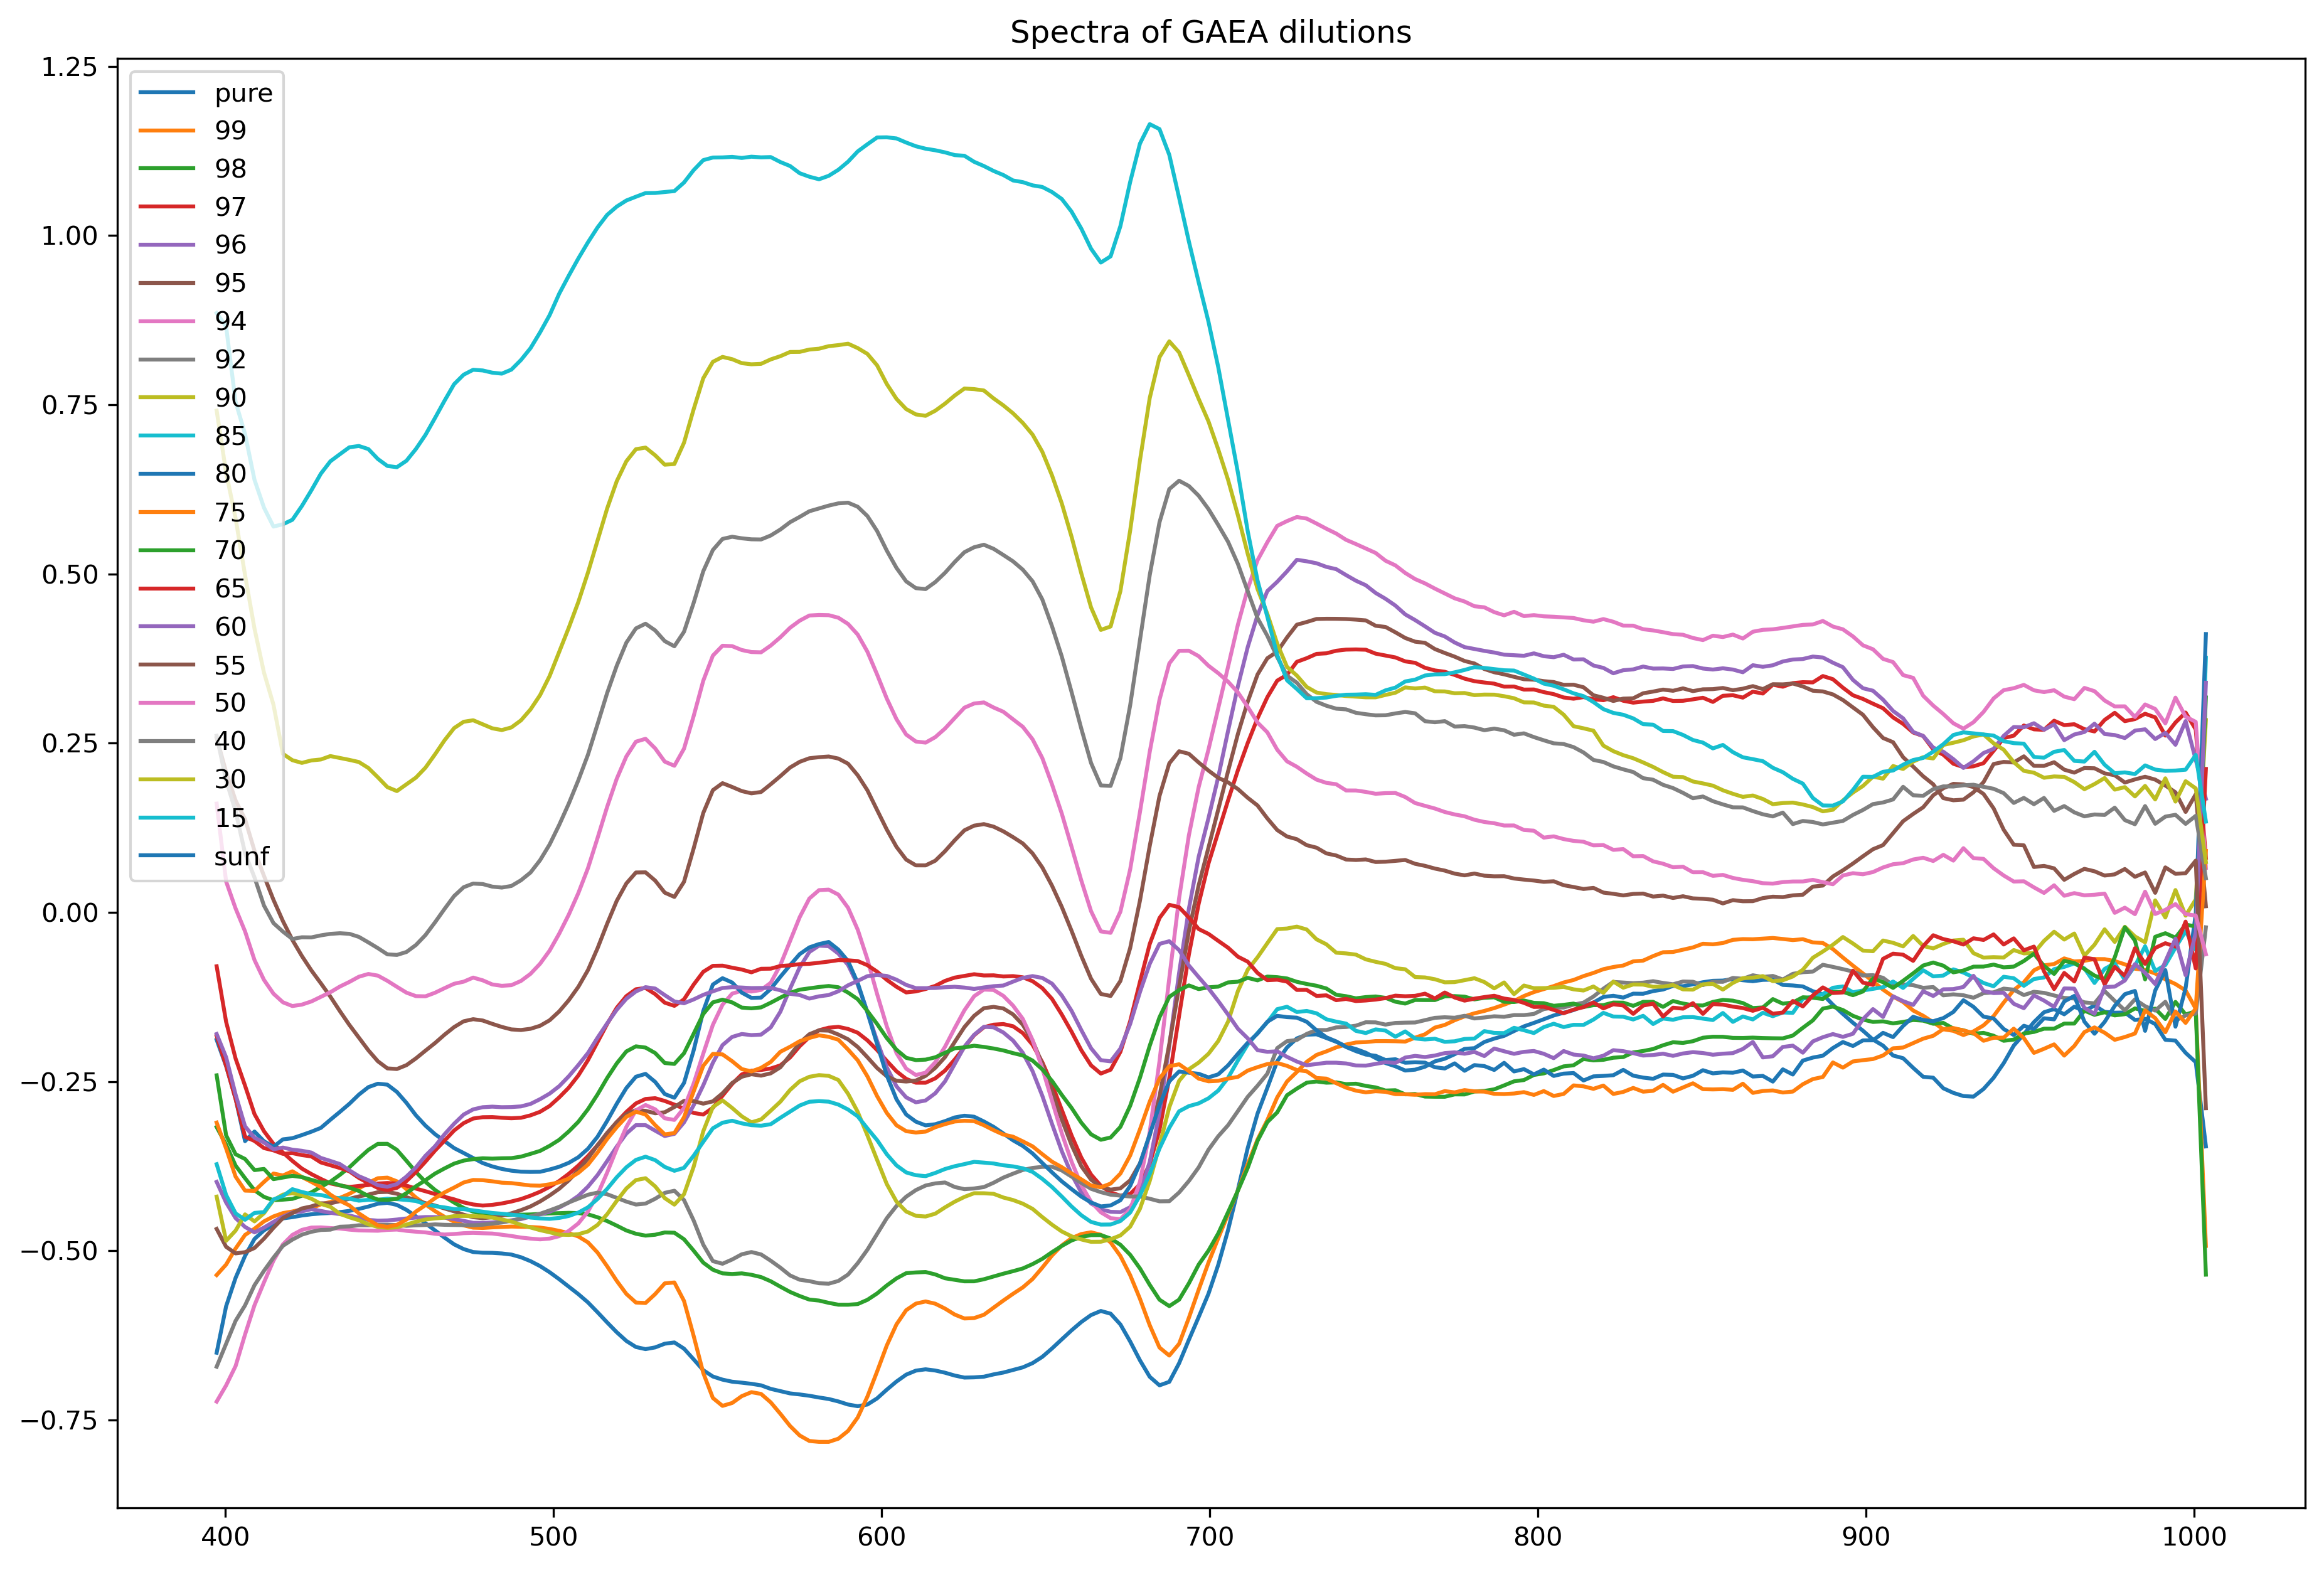

In [ ]:

plt.figure(figsize = (15, 10), dpi = 300)
plt.plot(waves, (ref_spec[ref_spec['oil'] == 'GAEA_100_0'].drop(columns = ['id', 'oil']).mean(axis = 0) - mu) / std, label = 'pure')
plt.plot(waves, (ref_spec[ref_spec['oil'] == 'GAEA_99_1'].drop(columns = ['id', 'oil']).mean(axis = 0)-mu) / std, label = '99')
plt.plot(waves, (ref_spec[ref_spec['oil'] == 'GAEA_98_2'].drop(columns = ['id', 'oil']).mean(axis = 0)-mu) / std, label = '98')
plt.plot(waves, (ref_spec[ref_spec['oil'] == 'GAEA_97_3'].drop(columns = ['id', 'oil']).mean(axis = 0)-mu) / std, label = '97')
plt.plot(waves, (ref_spec[ref_spec['oil'] == 'GAEA_96_4'].drop(columns = ['id', 'oil']).mean(axis = 0)-mu) / std, label = '96')
plt.plot(waves, (ref_spec[ref_spec['oil'] == 'GAEA_95_5'].drop(columns = ['id', 'oil']).mean(axis = 0)-mu) / std, label = '95')
plt.plot(waves, (ref_spec[ref_spec['oil'] == 'GAEA_94_6'].drop(columns = ['id', 'oil']).mean(axis = 0)-mu) / std, label = '94')
plt.plot(waves, (ref_spec[ref_spec['oil'] == 'GAEA_92_8'].drop(columns = ['id', 'oil']).mean(axis = 0)-mu) / std, label = '92')
plt.plot(waves, (ref_spec[ref_spec['oil'] == 'GAEA_90_10'].drop(columns = ['id', 'oil']).mean(axis = 0)-mu) / std, label = '90')
plt.plot(waves, (ref_spec[ref_spec['oil'] == 'GAEA_85_15'].drop(columns = ['id', 'oil']).mean(axis = 0)-mu) / std, label = '85')
plt.plot(waves, (ref_spec[ref_spec['oil'] == 'GAEA_80_20'].drop(columns = ['id', 'oil']).mean(axis = 0)-mu) / std, label = '80')
plt.plot(waves, (ref_spec[ref_spec['oil'] == 'GAEA_75_25'].drop(columns = ['id', 'oil']).mean(axis = 0)-mu) / std, label = '75')
plt.plot(waves, (ref_spec[ref_spec['oil'] == 'GAEA_70_30'].drop(columns = ['id', 'oil']).mean(axis = 0)-mu) / std, label = '70')
plt.plot(waves, (ref_spec[ref_spec['oil'] == 'GAEA_65_35'].drop(columns = ['id', 'oil']).mean(axis = 0)-mu) / std, label = '65')
plt.plot(waves, (ref_spec[ref_spec['oil'] == 'GAEA_60_40'].drop(columns = ['id', 'oil']).mean(axis = 0)-mu) / std, label = '60')
plt.plot(waves, (ref_spec[ref_spec['oil'] == 'GAEA_55_45'].drop(columns = ['id', 'oil']).mean(axis = 0)-mu) / std, label = '55')
plt.plot(waves, (ref_spec[ref_spec['oil'] == 'GAEA_50_50'].drop(columns = ['id', 'oil']).mean(axis = 0)-mu) / std, label = '50')
plt.plot(waves, (ref_spec[ref_spec['oil'] == 'GAEA_40_60'].drop(columns = ['id', 'oil']).mean(axis = 0)-mu) / std, label = '40')
plt.plot(waves, (ref_spec[ref_spec['oil'] == 'GAEA_30_70'].drop(columns = ['id', 'oil']).mean(axis = 0)-mu) / std, label = '30')
plt.plot(waves, (ref_spec[ref_spec['oil'] == 'GAEA_15_85'].drop(columns = ['id', 'oil']).mean(axis = 0)-mu) / std, label = '15')
plt.plot(waves, (ref_spec[ref_spec['oil'] == 'sunflower'].drop(columns = ['id', 'oil']).mean(axis = 0)-mu) / std, label = 'sunf')
plt.title('Spectra of GAEA dilutions')
plt.legend()
plt.show()


In [13]:
df_pure = df[df['oil'] == 'GAEA_100_0']
df_99 = df[df['oil'] == 'GAEA_99_1']
df_98 = df[df['oil'] == 'GAEA_98_2']
df_97 = df[df['oil'] == 'GAEA_97_3']
df_96 = df[df['oil'] == 'GAEA_96_4']
df_95 = df[df['oil'] == 'GAEA_95_5']
df_94 = df[df['oil'] == 'GAEA_94_6']
df_92 = df[df['oil'] == 'GAEA_92_8']
df_90 = df[df['oil'] == 'GAEA_90_10']
df_sunf = df[df['oil'] == 'Sunf_0_100']
ds_pure = UniversalDataset(root_dir = 'D:\\oil\\', meta = df_pure, load_hsi = True, load_mask = True, crop_size = 512, mask_dir = 'C:\\Users\\4spam\\evoo\\masking_business\\hand_masks\\')
ds_99 = UniversalDataset(root_dir = 'D:\\oil\\', meta = df_99, load_hsi = True, load_mask = True, crop_size = 512, mask_dir = 'C:\\Users\\4spam\\evoo\\masking_business\\hand_masks\\')
ds_98 = UniversalDataset(root_dir = 'D:\\oil\\', meta = df_98, load_hsi = True, load_mask = True, crop_size = 512, mask_dir = 'C:\\Users\\4spam\\evoo\\masking_business\\hand_masks\\')
ds_97 = UniversalDataset(root_dir = 'D:\\oil\\', meta = df_97, load_hsi = True, load_mask = True, crop_size = 512, mask_dir = 'C:\\Users\\4spam\\evoo\\masking_business\\hand_masks\\')
ds_96 = UniversalDataset(root_dir = 'D:\\oil\\', meta = df_96, load_hsi = True, load_mask = True, crop_size = 512, mask_dir = 'C:\\Users\\4spam\\evoo\\masking_business\\hand_masks\\')
ds_95 = UniversalDataset(root_dir = 'D:\\oil\\', meta = df_95, load_hsi = True, load_mask = True, crop_size = 512, mask_dir = 'C:\\Users\\4spam\\evoo\\masking_business\\hand_masks\\')
ds_94 = UniversalDataset(root_dir = 'D:\\oil\\', meta = df_94, load_hsi = True, load_mask = True, crop_size = 512, mask_dir = 'C:\\Users\\4spam\\evoo\\masking_business\\hand_masks\\')
ds_92 = UniversalDataset(root_dir = 'D:\\oil\\', meta = df_92, load_hsi = True, load_mask = True, crop_size = 512, mask_dir = 'C:\\Users\\4spam\\evoo\\masking_business\\hand_masks\\')
ds_90 = UniversalDataset(root_dir = 'D:\\oil\\', meta = df_90, load_hsi = True, load_mask = True, crop_size = 512, mask_dir = 'C:\\Users\\4spam\\evoo\\masking_business\\hand_masks\\')
ds_sunf = UniversalDataset(root_dir = 'D:\\oil\\', meta = df_sunf, load_hsi = True, load_mask = True, crop_size = 512, mask_dir = 'C:\\Users\\4spam\\evoo\\masking_business\\hand_masks\\')

Error loading mask: 'NoneType' object has no attribute 'read'
info: None
Error loading mask: 'NoneType' object has no attribute 'read'
info: None
Error loading mask: 'NoneType' object has no attribute 'read'
info: None
Error loading mask: 'NoneType' object has no attribute 'read'
info: None
Error loading mask: 'NoneType' object has no attribute 'read'
info: None


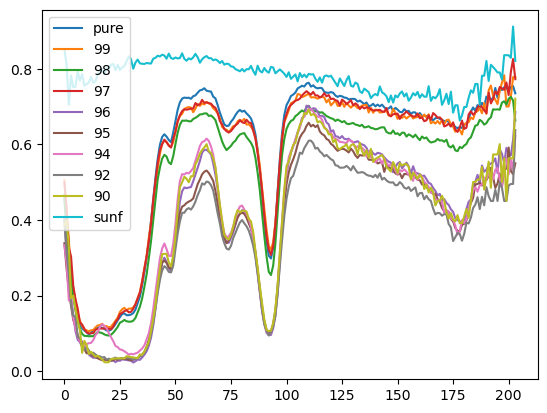

In [ ]:
plt.figure()
plt.plot(ds_pure[0]['hsi'][:, 512 // 2, 512 // 2], label = 'pure')
plt.plot(ds_99[0]['hsi'][:, 512 // 2, 512 // 2], label = '99')
plt.plot(ds_98[0]['hsi'][:, 512 // 2, 512 // 2], label = '98')
plt.plot(ds_97[0]['hsi'][:, 512 // 2, 512 // 2], label = '97')
plt.plot(ds_96[0]['hsi'][:, 512 // 2, 512 // 2], label = '96')
plt.plot(ds_95[0]['hsi'][:, 512 // 2, 512 // 2], label = '95')
plt.plot(ds_94[0]['hsi'][:, 512 // 2, 512 // 2], label = '94')
plt.plot(ds_92[0]['hsi'][:, 512 // 2, 512 // 2], label = '92')
plt.plot(ds_90[0]['hsi'][:, 512 // 2, 512 // 2], label = '90')
plt.plot(ds_sunf[0]['hsi'][:, 512 // 2, 512 // 2], label = 'sunf')
plt.legend()
plt.show()


In [15]:
import timeit
import torch

def fallback_mask(ref, cube, threshold = 0.9, corr_type = 'pearson'):
    device = cube.device
    dtype = cube.dtype
    ref = ref.to(device, dtype)

    B, H, W = cube.shape

    if corr_type == 'pearson':
        ref_centered = ref - ref.mean()
        cube_centered = cube - cube.mean(dim = 0, keepdim = True)

        ref_std = ref_centered.std()
        cube_std=  cube_centered.std(dim = 0, keepdim = True)

        ref_norm = ref_centered / (ref_std + 1e-10)
        cube_norm = cube_centered / (cube_std + 1e-10)

        corr = torch.einsum('b,bhw->hw', ref_norm, cube_norm) / B
    elif corr_type == 'cosine':
        ref_norm=  ref / (ref.norm(p = 2) + 1e-10)
        cube_norm = cube / (cube.norm(p = 2, dim = 0, keepdim = True) + 1e-10)
        corr = torch.einsum('b,bhw->hw', ref_norm, cube_norm)
    else:
        raise ValueError(f'Unknown correlation type: {corr_type}')
    
    mask = (corr >= threshold).float()
    return mask
sample = ds[0]
ref_pixel = sample['hsi'][:, 512 // 2, 512 // 2]


"""time = timeit.timeit(
    lambda: fallback_mask(ref = ref_pixel, cube = sample['hsi'], threshold = 0.9, corr_type = 'pearson'),
)"""

Error loading mask: 'NoneType' object has no attribute 'read'
info: None


"time = timeit.timeit(\n    lambda: fallback_mask(ref = ref_pixel, cube = sample['hsi'], threshold = 0.9, corr_type = 'pearson'),\n)"

In [22]:
import cv2
import numpy as np

In [24]:
import cv2
import matplotlib.pyplot as plt

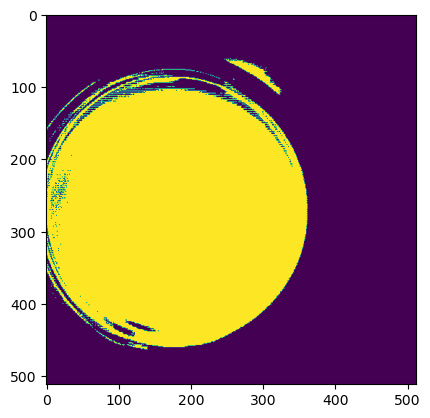

In [25]:
mask = fallback_mask(ref = ref_pixel, cube = sample['hsi'], threshold = 0.855, corr_type = 'pearson')
plt.imshow(mask.numpy().astype(np.uint8) * 255)

In [26]:
def extract_central_blob(mask, morph_kernel_size=0):
    """
    Extracts only the blob containing the center pixel from a mask.
    
    Args:
        mask: torch tensor of shape (1, H, W) or (H, W) with 0/1 (or 0..1) values
        morph_kernel_size: if > 0, applies morphological closing before component analysis
    
    Returns:
        filtered_mask: numpy array (H, W) with only the central blob, or None if center is background
    """
    # Prepare binary mask
    if isinstance(mask, torch.Tensor):
        m = mask.squeeze().detach().cpu().numpy()
    else:
        m = mask.squeeze()
    
    m = (m > 0).astype(np.uint8)
    H, W = m.shape
    center_point = (W // 2, H // 2)
    
    # Optional: morphological closing to merge nearby pixels
    if morph_kernel_size > 0:
        kernel = np.ones((morph_kernel_size, morph_kernel_size), np.uint8)
        m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, kernel)
    
    # Find connected components
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(m, connectivity=8)
    
    if num_labels <= 1:
        print("extract_central_blob: no foreground components found")
        return None
    
    # Get label of center pixel
    center_x, center_y = center_point
    if not (0 <= center_y < H and 0 <= center_x < W):
        print("extract_central_blob: center point out of bounds")
        return None
    
    center_label = labels[center_y, center_x]
    
    if center_label == 0:
        print("extract_central_blob: center pixel is background, finding closest blob")
        # Fallback: find closest blob to center
        min_dist = float('inf')
        closest_label = None
        for label_id in range(1, num_labels):
            centroid = centroids[label_id]
            dist = np.sqrt((centroid[0] - center_x)**2 + (centroid[1] - center_y)**2)
            if dist < min_dist:
                min_dist = dist
                closest_label = label_id
        if closest_label is None:
            return None
        center_label = closest_label
        print(f"extract_central_blob: using closest blob (label={center_label}, dist={min_dist:.1f})")
    else:
        print(f"extract_central_blob: found central blob (label={center_label}, area={stats[center_label, cv2.CC_STAT_AREA]})")
    
    # Extract only pixels belonging to the central blob
    filtered_mask = (labels == center_label).astype(np.uint8)
    
    return filtered_mask

In [30]:
def get_support_ellipse(mask, render_im = True, win_show = False):
    gray = mask.permute(1, 2, 0).numpy().astype(np.uint8) * 255
    edged = cv2.Canny(gray, 50, 150)
    contours, hierarchy = cv2.findContours(edged, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    ellipse = cv2.fitEllipse(contours[0])
    (c, (w, h), a)= ellipse
    print(c, w, h)
    rgb = cv2.cvtColor(mask.permute(1, 2, 0).numpy().astype(np.uint16) * 255, cv2.COLOR_GRAY2BGR)
    c = np.array(c).astype(np.uint16)
    ax = np.array([w * 0.95 // 2, h * 0.95 // 2]).astype(np.uint16)
    min_axis_size = 20  # minimum axis size
    scale_factor = 1.5  # scale up by this factor
    ax = np.maximum(ax.astype(float) * scale_factor, min_axis_size).astype(np.int32)
    im = None
    if render_im:
        im = cv2.ellipse(rgb, c, ax, a, 0, 360, (255, 0, 0), 1)
        if win_show:
            cv2.imshow('ellipse', im)
            key = cv2.waitKey(0)
            if key == ord('q'):
                print('Quit')
            cv2.destroyAllWindows() 
    return im, (c, ax, np.deg2rad(a))

extract_central_blob: found central blob (label=30, area=105666)
(119.32794952392578, 443.8092956542969) 2.789686918258667 7.198233604431152


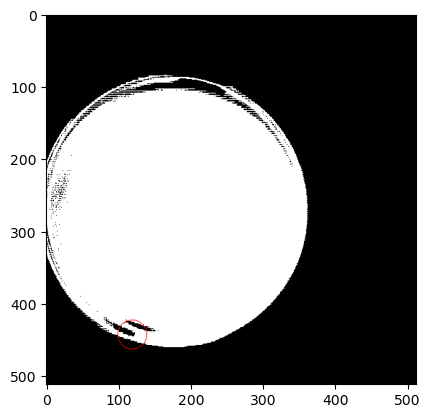

In [31]:
filtered_mask = extract_central_blob(mask)
plt.imshow(get_support_ellipse(torch.tensor(filtered_mask).unsqueeze(0))[0])

52

In [61]:
stats[52]

array([   21,   106,   341,   354, 90887], dtype=int32)

get_support_ellipse: found component 52 containing center
ellipse center, w, h: (57.71299362182617, 429.2222900390625) 46.09189987182617 57.09722900390625


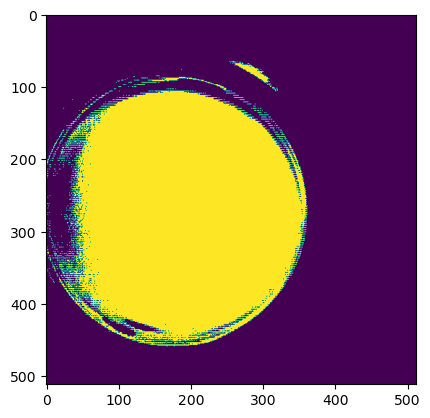

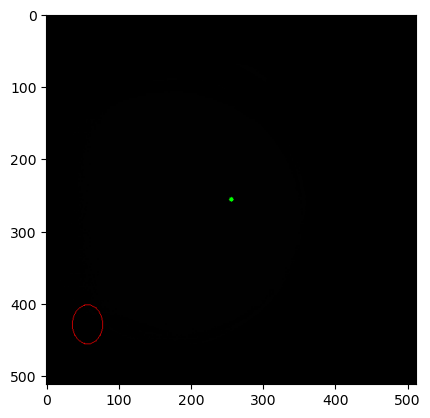

In [35]:
import cv2
mask = fallback_mask(ref = ref_pixel, cube = sample['hsi'], threshold = 0.9, corr_type = 'pearson')
plt.imshow(mask.numpy().astype(np.uint8) * 255)
plt.figure()
ellipse = get_support_ellipse(mask.unsqueeze(0))
plt.imshow(ellipse[0])

(204.07142639160156, 264.35565185546875) 98.00231170654297 181.0497283935547


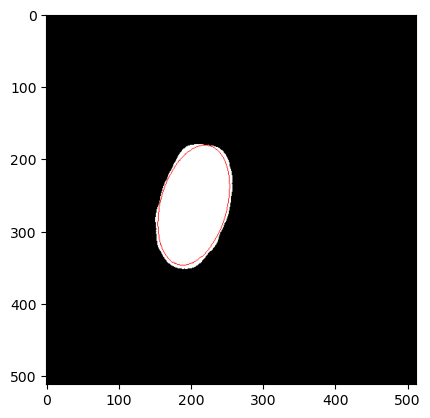

In [168]:
plt.imshow(get_support_ellipse(ds[11]['mask'])[0])

In [237]:
import random
def get_masked_random_circles(c, ax, a, radius = 20, base_im = None, n_circles = 10):
    # a as ellips tilt angle must be in radians
    im = np.zeros((512, 512, 3), dtype = np.uint16)
    if base_im is not None:
        im = base_im.copy()
    circle_centers = []
    for i in range(n_circles):
        theta = random.uniform(0, 2 * np.pi)
        r = np.sqrt(random.uniform(0, 1))
        x_local = r * (ax[0] - radius) * np.cos(theta)
        y_local = r * (ax[1] - radius) * np.sin(theta)
        cos_a = np.cos(a)
        sin_a = np.sin(a)
        x = c[0] + cos_a * x_local - sin_a * y_local
        y = c[1] + sin_a * x_local + cos_a * y_local
        circle_center = np.array([x, y]).astype(np.int16)
        circle_centers.append(circle_center)
        im = cv2.circle(im, circle_center, radius, (0, 0, 255), -1)
    return im, circle_centers

In [ ]:
import random
def get_masked_golden_circles(c, ax, a, radius = 20, base_im = None, n_circles = 10):
    # a as ellips tilt angle must be in radians

    golden_angle = np.pi * (3 - np.sqrt(5))

    cicrle_centers = []
    im = np.zeros((512, 512, 3), dtype = np.uint16)
    if base_im is not None:
        im = base_im.copy()

    for i in range(n_circles):
        r = np.sqrt(i / n_circles)
        theta = i * golden_angle
    
        x_local = r * (ax[0] - radius) * np.cos(theta)
        y_local = r * (ax[1] - radius) * np.sin(theta)
        cos_a = np.cos(a)
        sin_a = np.sin(a)
        x = c[0] + cos_a * x_local - sin_a * y_local
        y = c[1] + sin_a * x_local + cos_a * y_local
        circle_center = np.array([x, y]).astype(np.int16)
        cicrle_centers.append(circle_center)
        im = cv2.circle(im, circle_center, radius, (0, 0, 255), -1)
    return im, cicrle_centers


def get_masked_stratified_circles(c, ax, a, radius = 20, base_im = None, n_circles = 10):
    im = np.zeros((512, 512, 3), dtype = np.uint16)
    if base_im is not None:
        im = base_im.copy()
    n_divs = int(np.ceil(np.sqrt(n_circles)))
    circle_centers = []
    for i in range(n_divs):
        for j in range(n_divs):
            if len(circle_centers) < n_circles:
                u = (i + 0.5) / n_divs * 2 - 1
                v = (j + 0.5) / n_divs * 2 - 1
                scale = np.sqrt(u**2 + v**2) if (u**2 + v**2) > 0 else 1
                if scale < 1: # without scale filter they tend to leave the red ellipse zone
                    x_local = u * (ax[0] - radius)
                    y_local = v * (ax[1] - radius)
                    cos_a = np.cos(a)
                    sin_a = np.sin(a)
                    x=  c[0] + cos_a * x_local - sin_a * y_local
                    y = c[1] + sin_a * x_local + cos_a * y_local
                    circle_center = np.array([x, y]).astype(np.int16)
                    circle_centers.append(circle_center)
                    im = cv2.circle(im, circle_center, radius, (0, 0, 255), -1)
            else:
                break
    return im, circle_centers

def get_masked_rect(c, ax, a, base_im = None, n_rects = 10):
    im = np.zeros((512, 512, 3), dtype = np.uint16)
    if base_im is not None:
        im = base_im.copy()
    rect_w = ax[0] * np.sqrt(2)
    rect_h = ax[1] * np.sqrt(2)
    corners_local = np.array(
        [
            [-rect_w / 2, -rect_h / 2],
            [rect_w / 2, -rect_h / 2],
            [rect_w / 2, rect_h / 2],
            [-rect_w / 2, rect_h / 2]
        ]
    )
    cos_a = np.cos(a)
    sin_a = np.sin(a)
    R = np.array([
        [cos_a, -sin_a],
        [sin_a, cos_a]
    ])
    corners_rot = (R @ corners_local.T).T
    corners = (corners_rot + np.array(c)).astype(np.int32)

    for i in range(n_rects):
        for j in range(n_rects):
            if len(corners) < n_rects:
                x = i * rect_w / n_rects
                y = j * rect_h / n_rects
                corners.append(np.array([x, y]))
    corners_reshaped = corners.reshape((-1, 1, 2))
    im = cv2.fillPoly(im.astype(np.uint8), [corners_reshaped], (0, 0, 255))
    return im, corners

(204.07142639160156, 264.35565185546875) 98.00231170654297 181.0497283935547


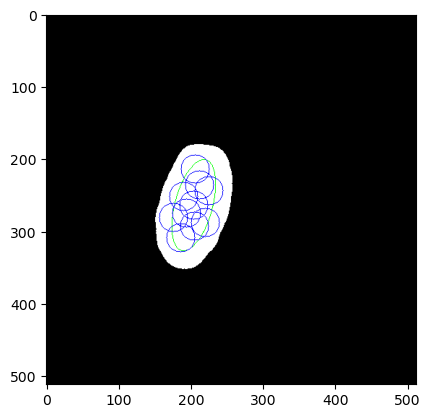

In [ ]:
mask = ds[11]['mask']
rgb = cv2.cvtColor(mask.permute(1, 2, 0).numpy().astype(np.uint16) * 255, cv2.COLOR_GRAY2BGR)
im, (c, ax, a) = get_support_ellipse(mask)
r = 20
im = cv2.ellipse(rgb, c, np.array([ax[0] - r, ax[1] - r]), np.rad2deg(a), 0, 360, (0, 255, 0), 1)
plt.imshow(im)
im, circle_center = get_masked_golden_circles(c, ax, a, r, im, n_circles = 10)
plt.imshow(im)


(187.97573852539062, 253.37655639648438) 268.1463623046875 342.0137023925781


C:\Users\4spam\AppData\Local\Temp\ipykernel_21144\2195880845.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


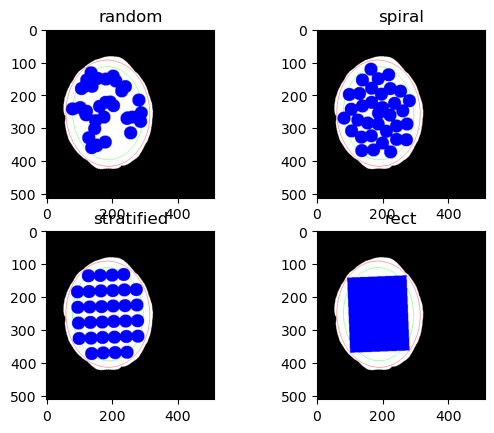

In [278]:
mask = ds[2]['mask']
rgb = cv2.cvtColor(mask.permute(1, 2, 0).numpy().astype(np.uint16) * 255, cv2.COLOR_GRAY2BGR)
im, (c, ax, a) = get_support_ellipse(mask)
r = 20
im = cv2.ellipse(rgb, c, np.array([ax[0] - r, ax[1] - r]), np.rad2deg(a), 0, 360, (0, 255, 0), 1)
im = cv2.ellipse(rgb, c, np.array([ax[0], ax[1]]), np.rad2deg(a), 0, 360, (255, 0, 0), 1)
# stratified circles
random_im, circle_centers = get_masked_random_circles(c, ax, a, r, im, n_circles = 35)
spiral_im, circle_centers = get_masked_golden_circles(c, ax, a, r, im, n_circles = 35)
stratified_im, circle_centers = get_masked_stratified_circles(c, ax, a, r, im, n_circles = 35)
im_rect, rect_corners = get_masked_rect(c, ax, a, im)
fig, ax = plt.subplots(2, 2)
ax[0, 0].imshow(random_im)
ax[0, 0].set_title('random')
ax[0, 1].imshow(spiral_im)
ax[0, 1].set_title('spiral')
ax[1, 0].imshow(stratified_im)
ax[1, 0].set_title('stratified')
ax[1, 1].imshow(im_rect)
ax[1, 1].set_title('rect')
fig.show()

# This is for coarse masking:

In [35]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
parent_dir = Path().resolve().parent
sys.path.insert(0, str(parent_dir))
#print(parent_dir)
from utils.dataset import UniversalDataset

In [36]:

import pandas as pd
df = pd.read_excel(parent_dir / 'pivot_table.xlsx', sheet_name = 'oil_dataset_final')
ref_spec = pd.read_csv('C:/Users/4spam/evoo/masking_business/ref_spectra.csv')

In [37]:
df['oil'].unique()

array(['sunflower', nan, 'GAEA_100_0', 'GAEA_99_1', 'GAEA_98_2',
       'GAEA_97_3', 'GAEA_96_4', 'GAEA_95_5', 'GAEA_94_6', 'GAEA_92_8',
       'GAEA_90_10', 'GAEA_85_15', 'GAEA_80_20', 'GAEA_75_25',
       'GAEA_70_30', 'GAEA_65_35', 'GAEA_60_40', 'GAEA_55_45',
       'GAEA_50_50', 'GAEA_40_60', 'GAEA_30_70', 'GAEA_15_85'],
      dtype=object)

In [38]:
df = df.dropna(subset = ['id'])
df = df[np.array([int(i) > 1000 for i in df['id'].values])]
df['id'] = df['id'].astype(int)
df.reset_index(drop = True, inplace = True)
df['id']

0      2599
1      2600
2      2601
3      2602
4      2603
       ... 
627    3252
628    3253
629    3254
630    3255
631    3256
Name: id, Length: 632, dtype: int32

In [39]:
spec_ids = df['id']
for i in spec_ids:
    ref_spec.loc[ref_spec['id'] == i, 'oil'] = df.loc[df['id'] == i, 'oil'].values[0]
ref_spec = ref_spec.dropna(subset = ['oil'])

In [154]:
import timeit
import torch

def fallback_mask(ref, cube, threshold = 0.9, corr_type = 'pearson'):
    device = cube.device
    dtype = cube.dtype
    ref = ref.to(device, dtype)

    B, H, W = cube.shape

    if corr_type == 'pearson':
        ref_centered = ref - ref.mean()
        cube_centered = cube - cube.mean(dim = 0, keepdim = True)

        ref_std = ref_centered.std()
        cube_std=  cube_centered.std(dim = 0, keepdim = True)

        ref_norm = ref_centered / (ref_std + 1e-10)
        cube_norm = cube_centered / (cube_std + 1e-10)

        corr = torch.einsum('b,bhw->hw', ref_norm, cube_norm) / B
    elif corr_type == 'cosine':
        ref_norm=  ref / (ref.norm(p = 2) + 1e-10)
        cube_norm = cube / (cube.norm(p = 2, dim = 0, keepdim = True) + 1e-10)
        corr = torch.einsum('b,bhw->hw', ref_norm, cube_norm)
    else:
        raise ValueError(f'Unknown correlation type: {corr_type}')
    
    mask = (corr >= threshold).float()
    return mask
    
def extract_central_blob(mask, morph_kernel_size=0):
    """
    Extracts the largest blob (by pixel count) from a mask.
    
    Args:
        mask: torch tensor of shape (1, H, W) or (H, W) with 0/1 (or 0..1) values
        morph_kernel_size: if > 0, applies morphological closing before component analysis
    
    Returns:
        filtered_mask: numpy array (H, W) with only the largest blob, or None if no foreground
    """
    # Prepare binary mask
    if isinstance(mask, torch.Tensor):
        m = mask.squeeze().detach().cpu().numpy()
    else:
        m = mask.squeeze()
    
    m = (m > 0).astype(np.uint8)
    H, W = m.shape
    
    # Optional: morphological closing to merge nearby pixels
    if morph_kernel_size > 0:
        kernel = np.ones((morph_kernel_size, morph_kernel_size), np.uint8)
        m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, kernel)
    
    # Find connected components
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(m, connectivity=8)
    
    if num_labels <= 1:
        print("extract_central_blob: no foreground components found")
        return None
    
    # Find largest blob by area (excluding background label 0)
    areas = stats[1:, cv2.CC_STAT_AREA]  # Skip label 0 (background)
    largest_label_idx = np.argmax(areas)
    largest_label = largest_label_idx + 1  # +1 because we skipped label 0
    
    largest_area = areas[largest_label_idx]
    print(f"extract_central_blob: found largest blob (label={largest_label}, area={largest_area})")
    
    # Extract only pixels belonging to the largest blob
    filtered_mask = (labels == largest_label).astype(np.uint8)
    
    return filtered_mask

def get_ellipse_from_bbox(mask):
    """
    Infers ellipse parameters from mask bounding box.
    
    Returns:
        (center, axes, angle_rad) where:
        - center: centroid of bounding box
        - axes: (half_width, half_height) from center to bounds
        - angle_rad: 0 (axis-aligned) or inferred from bbox orientation
    """
    # Get bounding box
    x, y, w, h = cv2.boundingRect((mask * 255).astype(np.uint8))
    
    # Center = centroid of bounding box
    center = (x + w / 2.0, y + h / 2.0)
    
    # Axes = half dimensions (distances from center to bounds)
    axes = (w / 2.0, h / 2.0)
    
    # Angle = 0 for axis-aligned rectangle
    angle_rad = 0.0
    
    return (center, axes, angle_rad)


import random
def get_masked_golden_circles(c, ax, a, radius = 20, base_im = None, n_circles = 10):
    # a as ellips tilt angle must be in radians

    golden_angle = np.pi * (3 - np.sqrt(5))

    cicrle_centers = []
    im = np.zeros((512, 512, 3), dtype = np.uint16)
    if base_im is not None:
        im = base_im.copy()

    for i in range(n_circles):
        r = np.sqrt(i / n_circles)
        theta = i * golden_angle
    
        x_local = r * (ax[0] - radius) * np.cos(theta)
        y_local = r * (ax[1] - radius) * np.sin(theta)
        cos_a = np.cos(a)
        sin_a = np.sin(a)
        x = c[0] + cos_a * x_local - sin_a * y_local
        y = c[1] + sin_a * x_local + cos_a * y_local
        circle_center = np.array([x, y]).astype(np.int16)
        cicrle_centers.append(circle_center)
        im = cv2.circle(im, circle_center, radius, (0, 0, 255), -1)
    return im, cicrle_centers

def get_masked_stratified_circles(c, ax, a, radius = 20, base_im = None, n_circles = 10):
    im = np.zeros((512, 512, 3), dtype = np.uint16)
    if base_im is not None:
        im = base_im.copy()
    n_divs = int(np.ceil(np.sqrt(n_circles)))
    circle_centers = []
    for i in range(n_divs):
        for j in range(n_divs):
            if len(circle_centers) < n_circles:
                u = (i + 0.5) / n_divs * 2 - 1
                v = (j + 0.5) / n_divs * 2 - 1
                scale = np.sqrt(u**2 + v**2) if (u**2 + v**2) > 0 else 1
                if scale < 1: # without scale filter they tend to leave the red ellipse zone
                    x_local = u * (ax[0] - radius)
                    y_local = v * (ax[1] - radius)
                    cos_a = np.cos(a)
                    sin_a = np.sin(a)
                    x=  c[0] + cos_a * x_local - sin_a * y_local
                    y = c[1] + sin_a * x_local + cos_a * y_local
                    circle_center = np.array([x, y]).astype(np.int16)
                    circle_centers.append(circle_center)
                    im = cv2.circle(im, circle_center, radius, (0, 0, 255), -1)
            else:
                break
    return im, circle_centers

def extract_circle_spectra(circle_centers, radius, sample, mask):
    """
    Extracts averaged spectra from circles, only including pixels within mask.
    
    Args:
        circle_centers: list/array of (x, y) tuples, shape (N, 2)
        radius: int, radius of circles
        sample: dict with 'hsi' (torch tensor, shape (204, H, W)), 'id', 'oil'
        mask: numpy array (H, W) with 0/1 values
    
    Returns:
        df: DataFrame with columns ['id', 'subid', 'oil', 'wave_0', ..., 'wave_203']
    """
    hsi = sample['hsi']  # (204, H, W)
    H, W = hsi.shape[1], hsi.shape[2]
    
    # Convert to numpy if needed
    if isinstance(hsi, torch.Tensor):
        hsi_np = hsi.numpy()
    else:
        hsi_np = hsi
    
    # Ensure mask is numpy
    if isinstance(mask, torch.Tensor):
        mask_np = mask.squeeze().cpu().numpy()
    else:
        mask_np = mask.squeeze()
    
    mask_np = (mask_np > 0).astype(bool)
    
    rows = []
    for subid, center in enumerate(circle_centers):
        x, y = int(center[0]), int(center[1])
        
        # Create circle mask
        circle_mask = np.zeros((H, W), dtype=np.uint8)
        cv2.circle(circle_mask, (x, y), radius, 255, -1)

        circle_mask = circle_mask > 0
        
        # Intersect with provided mask
        valid_pixels = circle_mask & mask_np

        pixels_count = valid_pixels.sum()
        
        if not valid_pixels.any():
            # No valid pixels, fill with NaN
            spectra = np.full(204, np.nan)
        else:
            # Extract and average spectra
            # hsi_np shape: (204, H, W)
            # valid_pixels shape: (H, W)
            spectra = hsi_np[:, valid_pixels].sum(axis=1) / pixels_count  # (204,)
        
        # Create row
        row = {
            'id': sample['id'],
            'subid': subid,
            'tare': sample['tare'],
            'evoo_conc': sample['evoo_conc'],
            'sunf_conc': sample['sunf_conc'],
            'power': pixels_count,
            'x': x,
            'y': y,
            'radius': radius
        }
        
        # Add wave columns
        for i in range(204):
            row[f'wave_{i}'] = spectra[i]
        
        rows.append(row)
    
    df = pd.DataFrame(rows)
    return df


def get_masked_rect(c, ax, a, base_im = None, n_rects = 10):
    im = np.zeros((512, 512, 3), dtype = np.uint16)
    if base_im is not None:
        im = base_im.copy()
    rect_w = ax[0] * np.sqrt(2)
    rect_h = ax[1] * np.sqrt(2)
    corners_local = np.array(
        [
            [-rect_w / 2, -rect_h / 2],
            [rect_w / 2, -rect_h / 2],
            [rect_w / 2, rect_h / 2],
            [-rect_w / 2, rect_h / 2]
        ]
    )
    cos_a = np.cos(a)
    sin_a = np.sin(a)
    R = np.array([
        [cos_a, -sin_a],
        [sin_a, cos_a]
    ])
    corners_rot = (R @ corners_local.T).T
    corners = (corners_rot + np.array(c)).astype(np.int32)
    '''
    for i in range(n_rects):
        for j in range(n_rects):
            if len(corners) < n_rects:
                x = i * rect_w / n_rects
                y = j * rect_h / n_rects
                corners.append(np.array([x, y]))
    
    corners_reshaped = corners.reshape((-1, 1, 2))
    '''
    im = cv2.fillPoly(im.astype(np.uint8), [corners], (0, 0, 255))
    
    return im, corners

import numpy as np

def cosine(a, b):
    """
    Cosine similarity between two 1D vectors a and b.
    """
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    denom = (np.linalg.norm(a) * np.linalg.norm(b)) + 1e-10
    return float(np.dot(a, b) / denom)

def extract_rect_spectra(rect_corners, n_subdivs, sample, mask, ref_spec, waves=None):
    """
    Splits rectangle into N x N subrectangles and extracts averaged spectra from each.
    
    Args:
        rect_corners: numpy array of shape (4, 2) with 4 corner points
        n_subdivs: int, number of subdivisions per side (creates n_subdivs x n_subdivs subrectangles)
        sample: dict with 'hsi' (torch tensor, shape (204, H, W)), 'id', 'oil', etc.
        mask: numpy array (H, W) with 0/1 values
        ref_spec: reference spectrum for cosine similarity
        waves: optional list of wavelength names
    
    Returns:
        df: DataFrame with columns ['id', 'subid', 'oil', 'wave_0', ..., 'wave_203', ...]
    """
    hsi = sample['hsi']  # (204, H, W)
    H, W = hsi.shape[1], hsi.shape[2]
    
    # Convert to numpy if needed
    if isinstance(hsi, torch.Tensor):
        hsi_np = hsi.numpy()
    else:
        hsi_np = hsi
    
    # Ensure mask is numpy boolean
    if isinstance(mask, torch.Tensor):
        mask_np = mask.squeeze().cpu().numpy()
    else:
        mask_np = mask.squeeze()
    
    mask_np = (mask_np > 0).astype(bool)
    
    # Create a mask for the entire rectangle
    rect_mask = np.zeros((H, W), dtype=np.uint8)
    cv2.fillPoly(rect_mask, [rect_corners], 255)
    rect_mask = rect_mask > 0
    
    # Get bounding box of rectangle to define grid
    x_coords = rect_corners[:, 0]
    y_coords = rect_corners[:, 1]
    x_min, x_max = int(x_coords.min()), int(x_coords.max())
    y_min, y_max = int(y_coords.min()), int(y_coords.max())
    
    # Calculate cell dimensions
    bbox_w = x_max - x_min
    bbox_h = y_max - y_min
    cell_w = bbox_w / n_subdivs
    cell_h = bbox_h / n_subdivs
    
    rows = []
    subid = 0
    
    for i in range(n_subdivs):
        for j in range(n_subdivs):
            # Cell boundaries in bounding box coordinates
            x1 = int(x_min + j * cell_w)
            y1 = int(y_min + i * cell_h)
            x2 = int(x_min + (j + 1) * cell_w)
            y2 = int(y_min + (i + 1) * cell_h)
            
            # Create cell mask (rectangle)
            cell_mask = np.zeros((H, W), dtype=bool)
            cell_mask[y1:y2, x1:x2] = True
            
            # Intersect with rectangle mask and provided mask
            valid_pixels = cell_mask & rect_mask & mask_np
            
            pixels_count = valid_pixels.sum()
            
            if not valid_pixels.any():
                # No valid pixels, fill with NaN
                spectra = np.full(204, np.nan)
            else:
                # Extract and average spectra - sum then divide by count of valid pixels
                # hsi_np shape: (204, H, W)
                # valid_pixels shape: (H, W)
                spectra = hsi_np[:, valid_pixels].sum(axis=1) / pixels_count  # (204,)
            
            # Create row
            row = {
                'id': sample['id'],
                'subid': subid,
                'tare': sample.get('tare', None),
                'evoo_conc': sample.get('evoo_conc', None),
                'sunf_conc': sample.get('sunf_conc', None),
                'power': pixels_count,
                'x': (x1 + x2) / 2,  # center x
                'y': (y1 + y2) / 2,  # center y
            }
            
            # Add cosine similarity if ref_spec provided
            if ref_spec is not None:
                row['cossim'] = cosine(spectra, ref_spec)
            
            # Add wave columns
            for wave_idx in range(204):
                if waves is not None:
                    row[waves[wave_idx]] = spectra[wave_idx]
                else:
                    row[f'wave_{wave_idx}'] = spectra[wave_idx]
            
            rows.append(row)
            subid += 1
    
    df = pd.DataFrame(rows)
    return df

def extract_circle_spectra(circle_centers, radius, sample, mask, ref_spec, waves = None):
    """
    Extracts averaged spectra from circles, only including pixels within mask.
    
    Args:
        circle_centers: list/array of (x, y) tuples, shape (N, 2)
        radius: int, radius of circles
        sample: dict with 'hsi' (torch tensor, shape (204, H, W)), 'id', 'oil'
        mask: numpy array (H, W) with 0/1 values
    
    Returns:
        df: DataFrame with columns ['id', 'subid', 'oil', 'wave_0', ..., 'wave_203']
    """
    hsi = sample['hsi']  # (204, H, W)
    H, W = hsi.shape[1], hsi.shape[2]
    
    # Convert to numpy if needed
    if isinstance(hsi, torch.Tensor):
        hsi_np = hsi.numpy()
    else:
        hsi_np = hsi
    
    # Ensure mask is numpy
    if isinstance(mask, torch.Tensor):
        mask_np = mask.squeeze().cpu().numpy()
    else:
        mask_np = mask.squeeze()
    
    mask_np = (mask_np > 0).astype(bool)
    
    rows = []
    for subid, center in enumerate(circle_centers):
        x, y = int(center[0]), int(center[1])
        
        # Create circle mask
        circle_mask = np.zeros((H, W), dtype=np.uint8)
        cv2.circle(circle_mask, (x, y), radius, 255, -1)

        circle_mask = circle_mask > 0
        
        # Intersect with provided mask
        valid_pixels = circle_mask & mask_np

        pixels_count = valid_pixels.sum()
        
        if not valid_pixels.any():
            # No valid pixels, fill with NaN
            spectra = np.full(204, np.nan)
        else:
            # Extract and average spectra
            # hsi_np shape: (204, H, W)
            # valid_pixels shape: (H, W)
            spectra = hsi_np[:, valid_pixels].sum(axis=1) / pixels_count  # (204,)
        
        # Create row
        row = {
            'id': sample['id'],
            'subid': subid,
            'tare': sample['tare'],
            'evoo_conc': sample['evoo_conc'],
            'sunf_conc': sample['sunf_conc'],
            'power': pixels_count,
            'x': x,
            'y': y,
            'radius': radius,
            'cossim': cosine(spectra, ref_spec)
        }
        
        # Add wave columns
        for i in range(204):
            if waves is not None:
                row[waves[i]] = spectra[i]
            else:
                row[f'wave_{i}'] = spectra[i]
        
        rows.append(row)
    
    df = pd.DataFrame(rows)
    return df


In [174]:
ds = UniversalDataset(root_dir = 'D:\\oil\\', meta = df, load_hsi = True, load_mask = True, crop_size = 512, mask_dir = 'C:\\Users\\4spam\\evoo\\masking_business\\fine_hand_masks\\')

In [188]:
def map_sample(i, method = 'rect', shrink_factor = 0.9, nbins = 36, visualize = False, radius = 15):
    waves = np.load('waves_specim_iq_204.npy')
    sample = ds[i]
    id = sample['id']
    sample_ref = ref_spec.loc[ref_spec['id'] == id].drop(columns = ['id', 'oil']).values
    mask = sample['mask']
    if mask is None:
        mask = fallback_mask(ref = torch.tensor(sample_ref).squeeze(), cube = sample['hsi'], threshold = 0.95, corr_type = 'pearson')
        mask = extract_central_blob(mask)
    else:
        mask = mask.squeeze().numpy()
    (c, (w, h), a) = get_ellipse_from_bbox(mask)


    vis = cv2.cvtColor((mask * 255).astype(np.uint8), cv2.COLOR_GRAY2RGB)
    ax = np.array([w * shrink_factor, h * shrink_factor]).astype(np.uint16)

    center_int = (int(c[0]), int(c[1]))
    axes_int = (int(ax[0]), int(ax[1]))
    angle_deg = np.rad2deg(a)

    cv2.ellipse(vis, center_int, axes_int, angle_deg, 0, 360, (0, 255, 0), 2)  # Green ellipse

    # Also draw center point
    cv2.circle(vis, center_int, 5, (255, 0, 0), -1)  # Red center

    if method == 'strat_circle':
        vis, circle_centers = get_masked_stratified_circles(c, ax, a, radius, vis, n_circles = 40)
        out = extract_circle_spectra(circle_centers, radius, sample, mask, sample_ref.squeeze(), waves = waves)
    elif method == 'golden_circle':
        vis, circle_centers = get_masked_golden_circles(c, ax, a, radius, vis, n_circles = 40)
        out = extract_circle_spectra(circle_centers, radius, sample, mask, sample_ref.squeeze(), waves = waves)
    elif method == 'random_circle':
        vis, circle_centers = get_masked_random_circles(c, ax, a, radius, vis, n_circles = 40)
        out = extract_circle_spectra(circle_centers, radius, sample, mask, sample_ref.squeeze(), waves = waves)
    elif method == 'rect':
        vis, rect_corners = get_masked_rect(c, ax, a, vis, n_rects = 36)
        out = extract_rect_spectra(rect_corners, 6, sample, mask, sample_ref.squeeze(), waves = waves)
    if visualize:
        plt.imshow(vis)
        plt.axis('off')
        plt.show()
    return out

Error loading mask: 'NoneType' object has no attribute 'read'
info: None
extract_central_blob: found largest blob (label=32, area=92525)


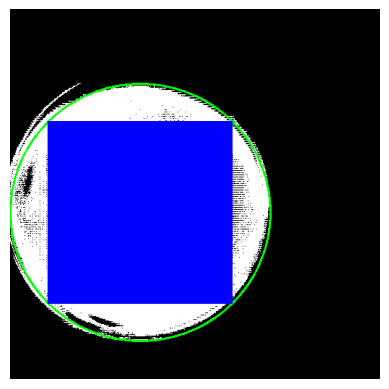

Error loading mask: 'NoneType' object has no attribute 'read'
info: None
extract_central_blob: found largest blob (label=16, area=65702)


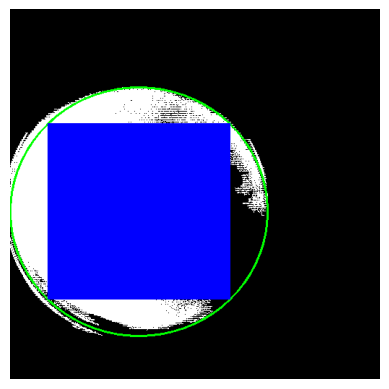

Error loading mask: 'NoneType' object has no attribute 'read'
info: None
extract_central_blob: found largest blob (label=12, area=59762)


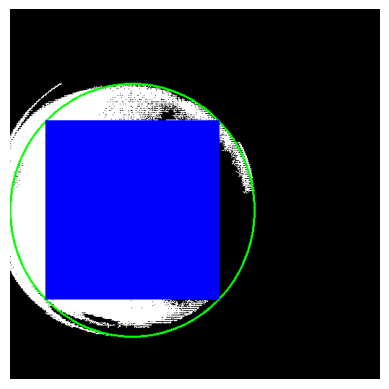

Error loading mask: 'NoneType' object has no attribute 'read'
info: None
extract_central_blob: found largest blob (label=13, area=61032)


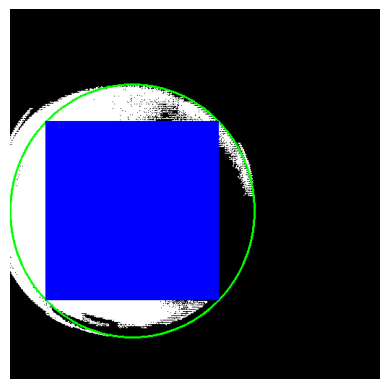

Error loading mask: 'NoneType' object has no attribute 'read'
info: None
extract_central_blob: found largest blob (label=16, area=43030)


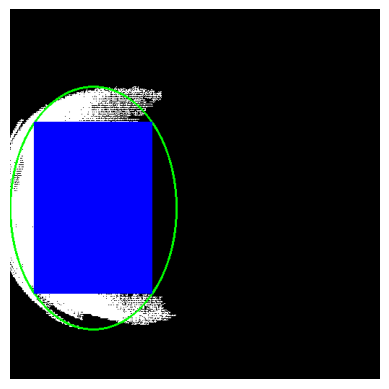

Error loading mask: 'NoneType' object has no attribute 'read'
info: None
extract_central_blob: found largest blob (label=17, area=49520)


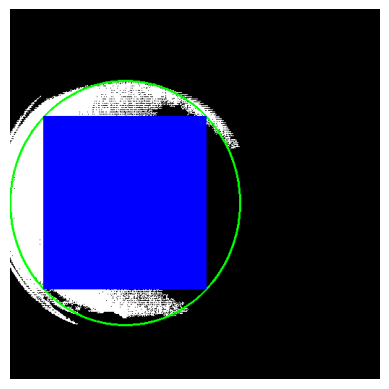

Error loading mask: 'NoneType' object has no attribute 'read'
info: None
extract_central_blob: found largest blob (label=14, area=55075)


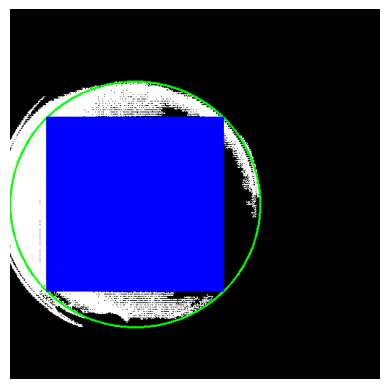

Error loading mask: 'NoneType' object has no attribute 'read'
info: None
extract_central_blob: found largest blob (label=17, area=39866)


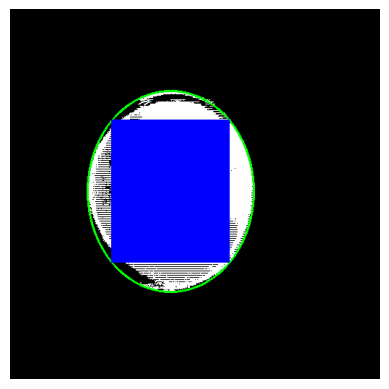

Error loading mask: 'NoneType' object has no attribute 'read'
info: None
extract_central_blob: found largest blob (label=22, area=40339)


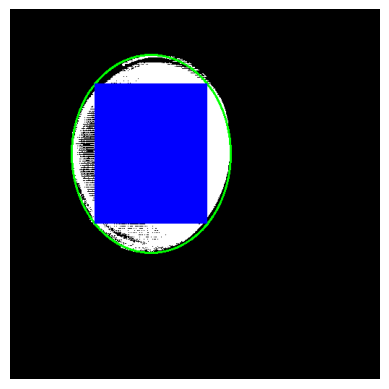

Error loading mask: 'NoneType' object has no attribute 'read'
info: None
extract_central_blob: found largest blob (label=23, area=39056)


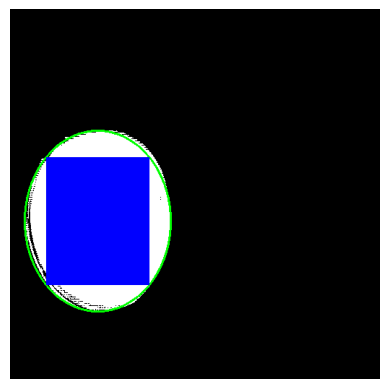

Error loading mask: 'NoneType' object has no attribute 'read'
info: None
extract_central_blob: found largest blob (label=20, area=35203)


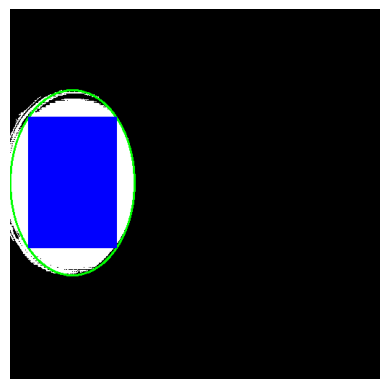

Error loading mask: 'NoneType' object has no attribute 'read'
info: None
extract_central_blob: found largest blob (label=16, area=42068)


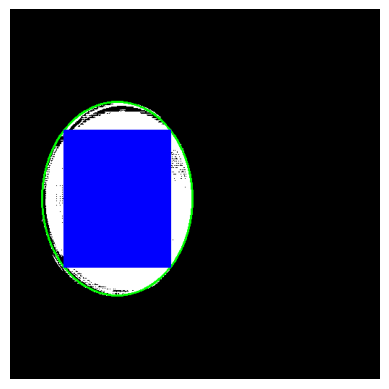

KeyboardInterrupt: 

In [189]:
results = []
for i in range(len(ds)):
    slice = map_sample(i, method = 'rect', shrink_factor = 1, nbins = 36, visualize = True, radius = 15)
    results.append(slice)
df = pd.concat(results)
df.to_csv('mapped_gt.csv', index = False)

In [181]:
gt = pd.read_csv('mapped_gt.csv')
len(gt['id'].unique())


619

In [182]:
ref = pd.read_csv('ref_spectra.csv')
len(ref['id'].unique())

619

In [183]:
gt['tare'].unique()

array(['petri', 'metal spoon', 'black plastic spoon', 'white plastic cup',
       'ceramic cup', 'spoon', 'paper cup', 'cut plastic cup'],
      dtype=object)

In [ ]:
slised = gt[[t in ['petri', 'cut plastic cup', 'spoon', 'ceramic cup'] for t in gt['tare']]].drop(columns = ['tare']).groupby('id').mean().sort_values(by = 'cossim', ascending = True)
slised


,subid,evoo_conc,sunf_conc,power,x,y,cossim,397.32,400.2,403.09,...,975.79,978.88,981.96,985.05,988.13,991.22,994.31,997.4,1000.49,1003.58
id,,,,,,,,,,,,,,,,,,,,,
2683,17.5,100.0,0.0,1351.583333,281.083333,252.083333,0.971739,0.504627,0.418767,0.348244,...,0.674199,0.674619,0.679724,0.689886,0.687092,0.692594,0.694838,0.696408,0.708939,0.704231
2707,17.5,100.0,0.0,318.611111,224.083333,276.083333,0.988543,0.517361,0.455532,0.403330,...,0.804788,0.793136,0.802888,0.792251,0.805889,0.794680,0.784841,0.806727,0.798171,0.815134
2916,17.5,94.0,6.0,574.444444,259.250000,249.000000,0.996078,0.399801,0.335114,0.273071,...,0.764724,0.783871,0.773007,0.762531,0.784233,0.770407,0.759727,0.746858,0.737142,0.702914
3126,17.5,60.0,40.0,502.472222,248.666667,257.666667,0.996195,0.427950,0.362840,0.293140,...,0.662290,0.634026,0.644089,0.657076,0.669115,0.631539,0.649106,0.607471,0.623116,0.697279
3104,17.5,65.0,35.0,852.166667,241.250000,256.083333,0.996230,0.447785,0.339384,0.294188,...,0.667064,0.676304,0.688367,0.654092,0.660401,0.669131,0.631576,0.646816,0.662956,0.707700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3186,17.5,50.0,50.0,779.222222,271.666667,257.250000,0.999968,0.552559,0.474484,0.406501,...,0.699828,0.713321,0.702937,0.720167,0.712434,0.733513,0.730057,0.724643,0.721078,0.722639
2629,17.5,0.0,100.0,2102.027778,238.083333,241.666667,0.999968,0.464879,0.466924,0.463730,...,0.461627,0.467950,0.474700,0.467939,0.478038,0.471349,0.486474,0.482027,0.478225,0.500923
3185,17.5,50.0,50.0,542.305556,263.250000,259.666667,0.999969,0.460973,0.398085,0.348935,...,0.610523,0.613387,0.614620,0.603325,0.606635,0.612826,0.622100,0.610698,0.621885,0.627982
